# 04 2D Segmentation

This notebook introduces the segmentation stage of the pipeline, focusing on the RGB stream. We will evaluate the performance of SAM2 for segmenting and tracking the forklift and kettle across the video frames.
We start with the **SAM2** Segmentation model as a baseline and evaluate to **SAM3** only if it provides a meaningful improvement without excessive computational cost.


### In this notebook, we will:

1. **RGB stream sanity check**
   - Load the `.vrs` file with `projectaria_tools`.
   - Validate RGB stream access and timestamp consistency.

2. **Prompt initialization frames**
   - Select only a few clean frames to initialize prompts.

3. **SAM2 baseline segmentation**
   - Multi-object prompting (forklift and kettle).
   - Mask propagation across time.

4. **Failure analysis and diagnostics**
   - Inspect drift, mask merging, holes, and missing thin parts.
   - Produce visual overlays for qualitative review.

5. **Targeted stress windows**
   - Evaluate difficult conditions: camera in/out motion, overlap, reflective kettle surfaces, and thin forklift structures.

6. **Quantitative temporal metrics**
   - Mask area stability, centroid jitter, temporal IoU, continuity/drop rate.

7. **SAM3 decision gate**
   - Run SAM3 only on critical windows.
   - Compare quality vs computational cost.

8. **Timestamp-aligned export**
   - Save masks and metadata with exact frame timestamps for later alignment with Aria trajectory/3D outputs.


As a sample, we will use `kettle_and_forklift_recording.vrs` located in the local `data/raw/kettle_and_forklift/` directory.

For this notebook, we used as references:
* SAM2: https://github.com/facebookresearch/sam2
* SAM3: https://github.com/facebookresearch/sam3


## 4.1 RGB Stream Sanity Check

In this section we will perform a sanity check on the RGB stream by defining input/output paths and reading one RGB frame to validate decoding and timestamps.

We will create a grid of RGB frames sampled every 10 seconds to visually inspect the video content and confirm that we can access the frames correctly.

We will use some helper functions defined in `scripts/aria_dataset.py`

In [1]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch

from projectaria_tools.core import data_provider

# depends on installed projectaria_tools build
try:
    from projectaria_tools.core.sensor_data import TimeDomain, TimeQueryOptions
except Exception:
    TimeDomain = None
    TimeQueryOptions = None

In [2]:
# setup paths and validate VRS access
VRS_PATH = os.path.join("..", "data", "raw", "kettle_and_forklift", "kettle_and_forklift_recording.vrs")

OUT_ROOT = os.path.join("..", "data", "outputs", "segmentation", "kettle_and_forklift")
Path(OUT_ROOT).mkdir(parents=True, exist_ok=True)

if not os.path.exists(VRS_PATH):
    raise FileNotFoundError(f"VRS file not found: {os.path.abspath(VRS_PATH)}")

print("VRS path:", os.path.abspath(VRS_PATH))
print("Output root:", os.path.abspath(OUT_ROOT))


VRS path: c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\raw\kettle_and_forklift\kettle_and_forklift_recording.vrs
Output root: c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\outputs\segmentation\kettle_and_forklift


In [3]:
# Helper functions for VRS access and RGB frame retrieval

from projectaria_tools.core import sensor_data
import sys
from pathlib import Path

# Add project root to sys.path
cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent]

project_root = next(
    (p for p in candidates if (p / "scripts" / "aria_dataset.py").exists()),
    None
)
if project_root is None:
    raise RuntimeError(f"Cannot find scripts/aria_dataset.py from cwd={cwd}")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from scripts.aria_dataset import _extract_image_array_from_sample


def create_provider(vrs_path: str):
    """Create a VRS data provider for the given path."""
    provider = data_provider.create_vrs_data_provider(vrs_path)
    if provider is None:
        raise RuntimeError("Failed to create VRS data provider.")
    return provider


def resolve_rgb_stream(provider, rgb_stream_id_str: str = "214-1"):
    """Enumerate all streams and find the one matching the RGB stream id string."""
    rgb_candidates = [sid for sid in provider.get_all_streams() if str(sid) == rgb_stream_id_str]
    if len(rgb_candidates) == 0:
        raise RuntimeError(f"RGB stream {rgb_stream_id_str} not found in VRS.")
    rgb_stream_id = rgb_candidates[0]
    rgb_label = provider.get_label_from_stream_id(rgb_stream_id)
    rgb_sample_count = provider.get_num_data(rgb_stream_id)
    return rgb_label, rgb_stream_id, rgb_sample_count


def get_rgb_timestamps_ns(provider, stream_id, sample_count):
    """Get an array of timestamps in nanoseconds for all samples in the RGB stream."""
    ts = np.empty(sample_count, dtype=np.int64)
    for i in range(sample_count):
        s = provider.get_sensor_data_by_index(stream_id, i)
        ts[i] = s.get_time_ns(sensor_data.TimeDomain.DEVICE_TIME)
    return ts


def get_rgb_frame_by_index(provider, stream_id, index: int):
    """Get the RGB frame as a numpy array for the sample at the given index in the RGB stream."""
    sample = provider.get_sensor_data_by_index(stream_id, int(index))
    return _extract_image_array_from_sample(sample)

RGB stream label: camera-rgb
RGB stream id: 214-1
RGB sample count: 1551


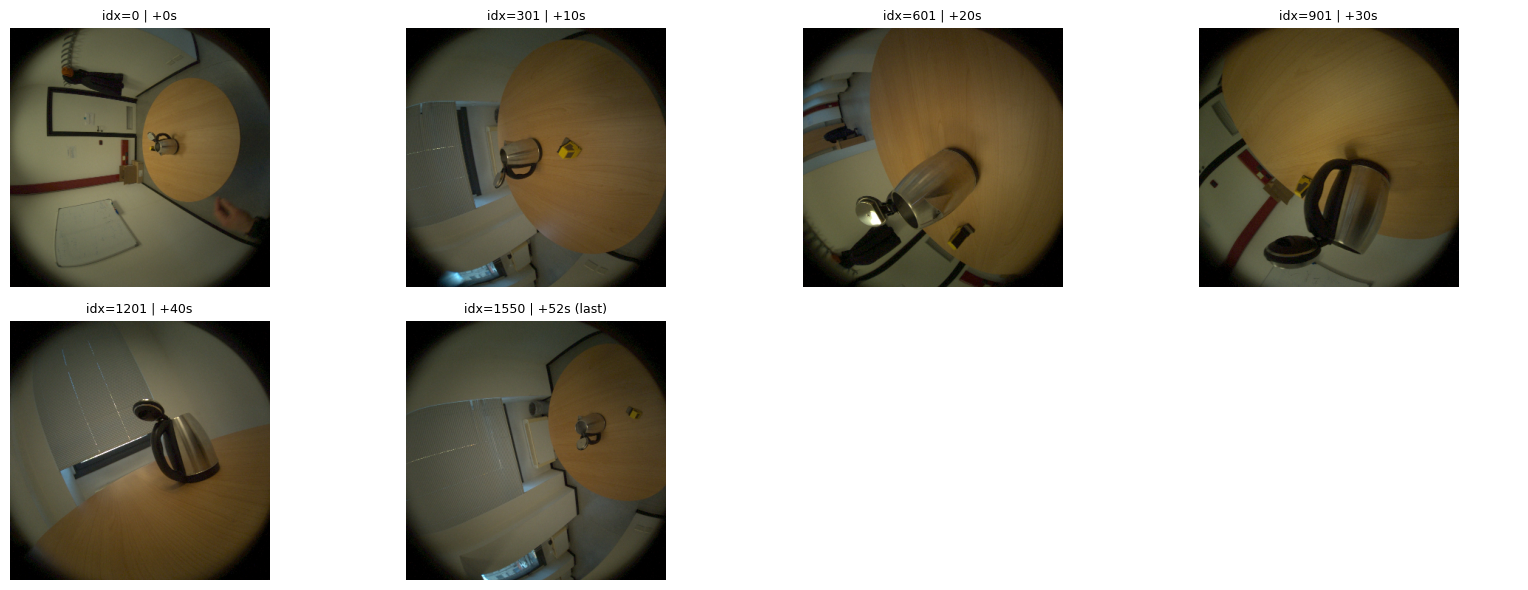

In [4]:
# as a sanity check we will create a grid with a frame every 10s

provider = create_provider(VRS_PATH)

rgb_label, rgb_stream_id, rgb_sample_count = resolve_rgb_stream(
    provider, rgb_stream_id_str="214-1"
)
rgb_timestamps_ns = get_rgb_timestamps_ns(provider, rgb_stream_id, rgb_sample_count)

print("RGB stream label:", rgb_label)
print("RGB stream id:", rgb_stream_id)
print("RGB sample count:", rgb_sample_count)

base_ts_ns = int(rgb_timestamps_ns[0])
last_ts_ns = int(rgb_timestamps_ns[-1])
duration_s = int((last_ts_ns - base_ts_ns) // 1_000_000_000)

step_s = 10
target_offsets_s = list(range(0, duration_s + 1, step_s))

# Get closest sample indices for target offsets
sample_indices = []
for off_s in target_offsets_s:
    target_ts_ns = base_ts_ns + off_s * 1_000_000_000
    idx = int(np.searchsorted(rgb_timestamps_ns, target_ts_ns, side="left"))
    if idx >= rgb_sample_count:
        idx = rgb_sample_count - 1
    sample_indices.append(idx)

# Force the last frame if it is not already included
if sample_indices[-1] != (rgb_sample_count - 1):
    sample_indices[-1] = rgb_sample_count - 1

# Remove duplicates while preserving order
seen = set()
sample_indices = [i for i in sample_indices if not (i in seen or seen.add(i))]

# Grid settings
downsample = 4  # 1=no resize, 2=1/2, 4=1/4
ncols = 4
nrows = (len(sample_indices) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = np.array(axes).reshape(nrows, ncols)

# Display selected frames
for k in range(nrows * ncols):
    r, c = divmod(k, ncols)
    ax = axes[r, c]
    ax.axis("off")

    if k >= len(sample_indices):
        continue

    idx = sample_indices[k]
    frame_rgb = get_rgb_frame_by_index(provider, rgb_stream_id, idx)
    frame_small = frame_rgb[::downsample, ::downsample]

    rel_s = int(round((int(rgb_timestamps_ns[idx]) - base_ts_ns) / 1e9))
    is_last = (idx == rgb_sample_count - 1)

    ax.imshow(frame_small)
    ax.set_title(f"idx={idx} | +{rel_s}s{' (last)' if is_last else ''}", fontsize=9)

plt.tight_layout()
plt.show()

## 4.2 Prompt Initialization Frames

SAM-based segmentation relies on prompts to guide the model in identifying the target objects.
In this section, we select a small set of clean RGB frames to initialize segmentation prompts.
We use evenly spaced candidates and then define a final list of initialization indices.

In [5]:
# Select evenly spaced candidate frames for prompt initialization

# Number of candidate frames to inspect
n_candidates = 8 # arbitrary choice

# Avoid first and last frame for initialization
start_idx = max(0, int(0.05 * rgb_sample_count))
end_idx = min(rgb_sample_count - 1, int(0.95 * rgb_sample_count))

candidate_indices = np.linspace(start_idx, end_idx, n_candidates, dtype=int).tolist()
candidate_indices = list(dict.fromkeys(candidate_indices))  # keep unique, preserve order

print("Candidate indices:", candidate_indices)

Candidate indices: [77, 276, 475, 675, 874, 1074, 1273, 1473]


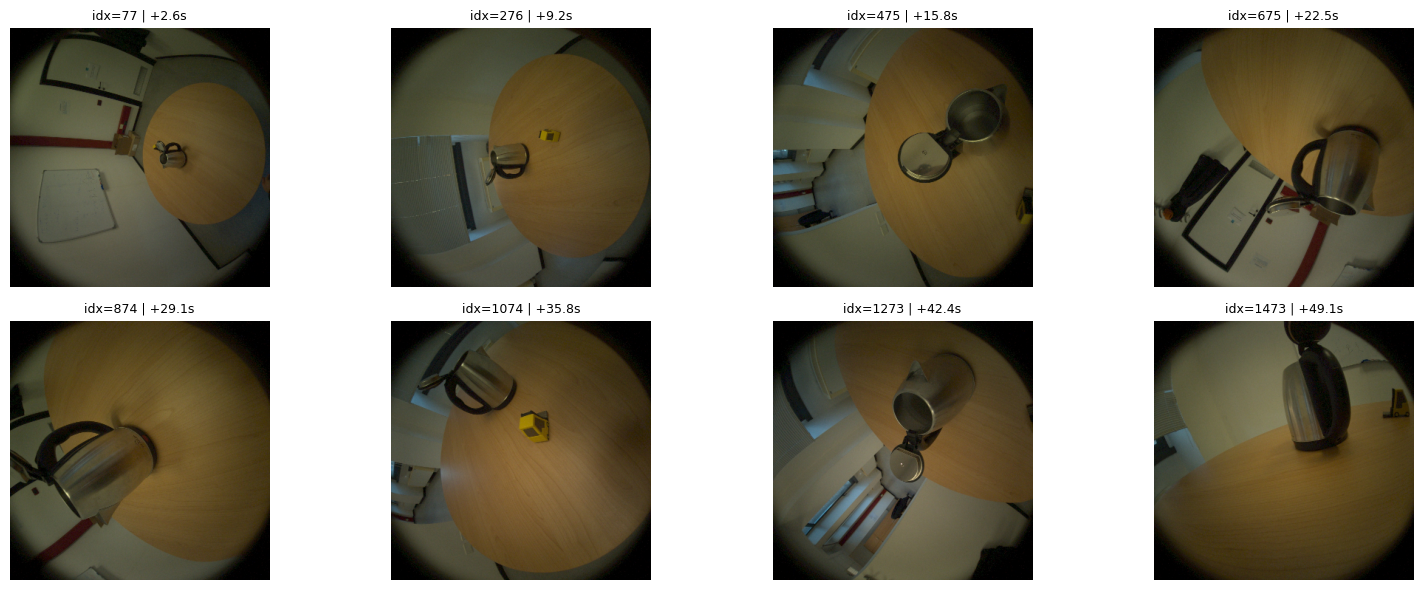

In [6]:
# Visualize candidate frames

downsample = 4
ncols = 4
nrows = (len(candidate_indices) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = np.array(axes).reshape(nrows, ncols)

for k in range(nrows * ncols):
    ax = axes.flat[k]
    ax.axis("off")
    if k >= len(candidate_indices):
        continue

    idx = candidate_indices[k]
    frame_rgb = get_rgb_frame_by_index(provider, rgb_stream_id, idx)
    frame_small = frame_rgb[::downsample, ::downsample]

    rel_s = (int(rgb_timestamps_ns[idx]) - int(rgb_timestamps_ns[0])) / 1e9
    ax.imshow(frame_small)
    ax.set_title(f"idx={idx} | +{rel_s:.1f}s", fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# Manual prompt initialization frames selected after visual inspection
PROMPT_INIT_INDICES = [230, 373, 911, 1131]
PROMPT_FRAME_IDX = PROMPT_INIT_INDICES[2] # 911 is the best

print("Selected PROMPT_INIT_INDICES:", PROMPT_INIT_INDICES)
print("PROMPT_FRAME_IDX:", PROMPT_FRAME_IDX)

Selected PROMPT_INIT_INDICES: [230, 373, 911, 1131]
PROMPT_FRAME_IDX: 230


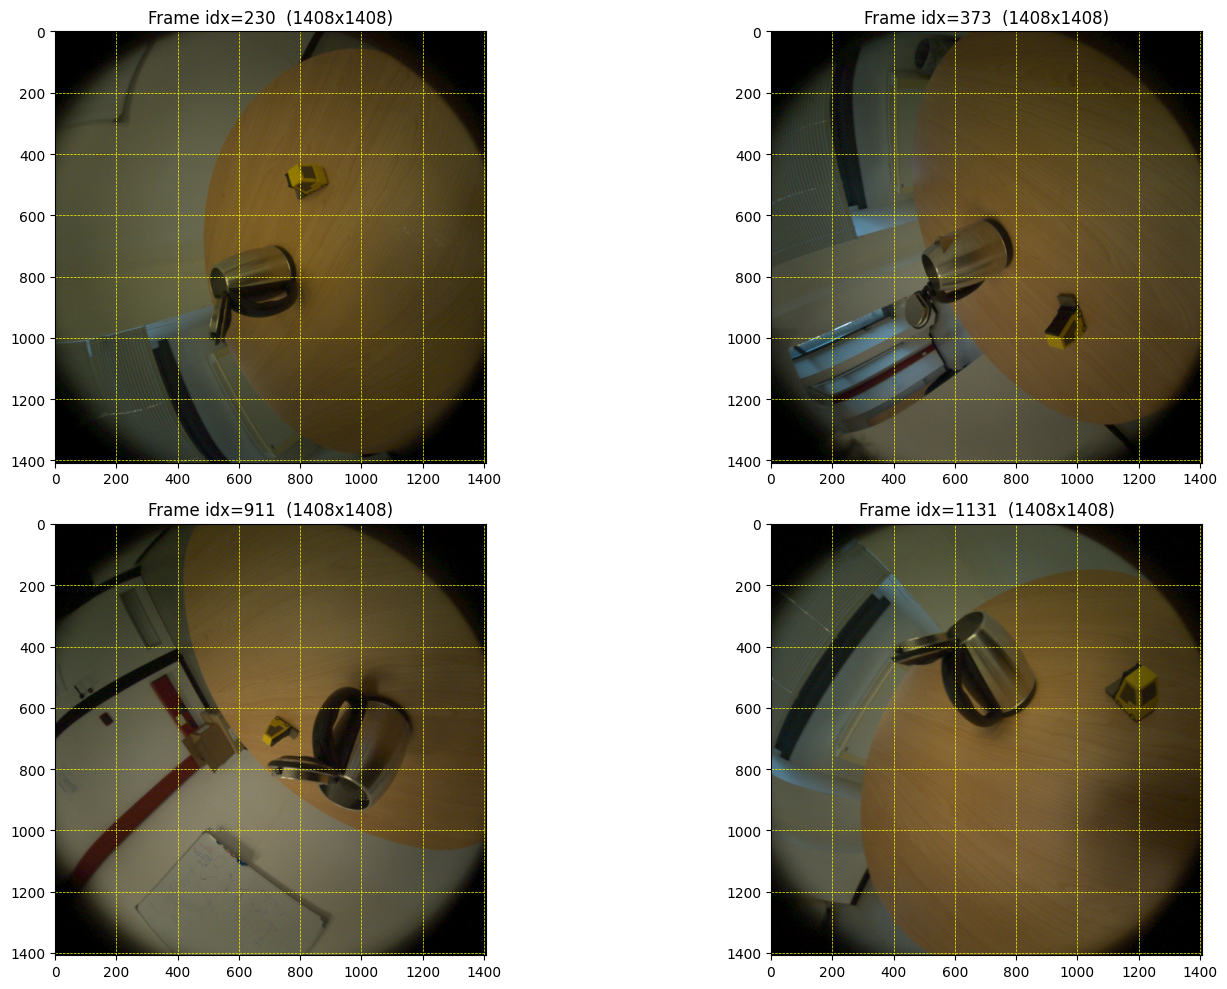

In [17]:
# Visualize the 4 selected prompt frames
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for ax, idx in zip(axes, PROMPT_INIT_INDICES):
    frame_rgb = get_rgb_frame_by_index(provider, rgb_stream_id, idx)
    h, w = frame_rgb.shape[:2]
    ax.imshow(frame_rgb)
    ax.set_title(f"Frame idx={idx}  ({w}x{h})")
    ax.axis("on")
    ax.set_xticks(np.arange(0, w + 1, 200))
    ax.set_yticks(np.arange(0, h + 1, 200))
    ax.grid(color="yellow", linestyle="--", linewidth=0.5)

plt.tight_layout()
plt.show()

### Candidate Frame Selection Criteria

Candidate frames are **not** selected randomly.

The selection follows a deterministic rule:

1. Define a central window of the RGB stream:
   - `start_idx = 5%` of the total RGB frame count
   - `end_idx = 95%` of the total RGB frame count  
   This avoids very early and very late frames, which are often less stable for prompt initialization.

2. Select `n_candidates` **evenly spaced** indices between `start_idx` and `end_idx` using:
   - `np.linspace(start_idx, end_idx, n_candidates, dtype=int)`

3. Remove potential duplicates while preserving order:
   - useful when the sequence is short or when `n_candidates` is high.

As a result, for the same video and parameters (`n_candidates`, 5%-95% range), the selected candidate frames are always the same.

## 4.3 SAM2 Baseline Segmentation

In this section we will use the SAM2 model to perform segmentation on the RGB frames using box prompts for the forklift and kettle.

The workflow is:

1. Export the RGB video frames to a folder that SAM2 can read.
2. Load the SAM2 video predictor.
3. Define object prompts for the target classes:
   - forklift
   - kettle
4. Initialize the masks on one clean frame.
5. Propagate the masks across the full video.
6. Save masks and metadata for later diagnostics and quantitative analysis.

For the baseline, we use **box prompts** because they are stable, simple to inspect, and appropriate for the first segmentation pass.

In [8]:
from PIL import Image
import json
from collections import defaultdict

# SAM2 uses GPU when available
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DEVICE: cuda


In [9]:
# Output folders
SAM2_ROOT = Path(OUT_ROOT) / "sam2"
SAM2_FRAMES_DIR = SAM2_ROOT / "frames"
SAM2_MASKS_DIR = SAM2_ROOT / "masks"
SAM2_VIS_DIR = SAM2_ROOT / "visualizations"

SAM2_FRAMES_DIR.mkdir(parents=True, exist_ok=True)
SAM2_MASKS_DIR.mkdir(parents=True, exist_ok=True)
SAM2_VIS_DIR.mkdir(parents=True, exist_ok=True)


In [ ]:
# 4.1 Function to export RGB frames as images for SAM2 processing
def export_rgb_frames(
    provider,
    stream_id,
    sample_count: int,
    out_dir: Path,
    ext: str = "jpg",
    jpeg_quality: int = 95,
    force_rebuild: bool = False,
):
    """
    Export RGB frames as jpg images:
    000000.jpg, 000001.jpg, etc...
    If cache is complete and force_rebuild=False, skip export.
    """
    out_dir.mkdir(parents=True, exist_ok=True)
    ext = ext.lower().lstrip(".")

    # Check cache completeness
    expected_files = [out_dir / f"{i:06d}.{ext}" for i in range(sample_count)]
    cache_complete = all(p.exists() for p in expected_files)

    if cache_complete and not force_rebuild:
        print(f"Frame cache already complete. Skipping export: {out_dir}")
        return

    # If force_rebuild, clear existing files
    if force_rebuild:
        for p in out_dir.glob(f"*.{ext}"):
            p.unlink()

    # Export frames
    for i in range(sample_count):
        out_path = out_dir / f"{i:06d}.jpg"
        if out_path.exists() and not force_rebuild:
            continue

        frame_rgb = get_rgb_frame_by_index(provider, stream_id, i)
        img = Image.fromarray(frame_rgb)
        img.save(out_path, quality=jpeg_quality, subsampling=0, optimize=True)

    print(f"Export completed: {out_dir} ({sample_count} frames, .jpg)")


export_rgb_frames(
    provider=provider,
    stream_id=rgb_stream_id,
    sample_count=rgb_sample_count,
    out_dir=SAM2_FRAMES_DIR,
    ext="jpg",
    jpeg_quality=95,
    force_rebuild=False,
)

Frame cache already complete. Skipping export: ..\data\outputs\segmentation\kettle_and_forklift\sam2\frames


In [11]:
from pathlib import Path

# Validate SAM2 config and checkpoint paths
SAM2_CONFIG_FILE = Path("..") / "third_party" / "sam2" / "sam2" / "configs" / "sam2" / "sam2_hiera_l.yaml"
SAM2_CHECKPOINT = Path("..") / "checkpoints" / "sam2_hiera_large.pt"

if not SAM2_CONFIG_FILE.exists():
    raise FileNotFoundError(f"SAM2 config non trovato: {SAM2_CONFIG_FILE.resolve()}")
if not SAM2_CHECKPOINT.exists():
    raise FileNotFoundError(f"SAM2 checkpoint non trovato: {SAM2_CHECKPOINT.resolve()}")

print("SAM2_CONFIG_FILE:", SAM2_CONFIG_FILE.resolve())
print("SAM2_CHECKPOINT:", SAM2_CHECKPOINT.resolve())

SAM2_CONFIG_FILE: C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\third_party\sam2\sam2\configs\sam2\sam2_hiera_l.yaml
SAM2_CHECKPOINT: C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\checkpoints\sam2_hiera_large.pt


In [ ]:
from sam2.build_sam import build_sam2_video_predictor

#! Hydra wants a config-name, not an absolute path
SAM2_CONFIG_NAME = "configs/sam2/sam2_hiera_l.yaml"

# 4.2 Initialize SAM2 predictor
sam2_predictor = build_sam2_video_predictor(
    config_file=SAM2_CONFIG_NAME,
    ckpt_path=str(SAM2_CHECKPOINT),
    device=DEVICE,
)

print("Loaded SAM2 predictor.")

Loaded SAM2 predictor.


In [ ]:
# 4.3 Define box prompts for the target objects on one clean frame

# NOTE: adjust these coordinates after visual inspection if needed
PROMPT_FRAME_IDX = PROMPT_INIT_INDICES[0]

# Example boxes: [x0, y0, x1, y1]
BOX_PROMPTS = {
    "forklift": [80, 120, 900, 900],
    "kettle": [950, 180, 1450, 980],
}

print("PROMPT_FRAME_IDX:", PROMPT_FRAME_IDX)
print("BOX_PROMPTS:", BOX_PROMPTS)

PROMPT_FRAME_IDX: 77
BOX_PROMPTS: {'forklift': [80, 120, 900, 900], 'kettle': [950, 180, 1450, 980]}


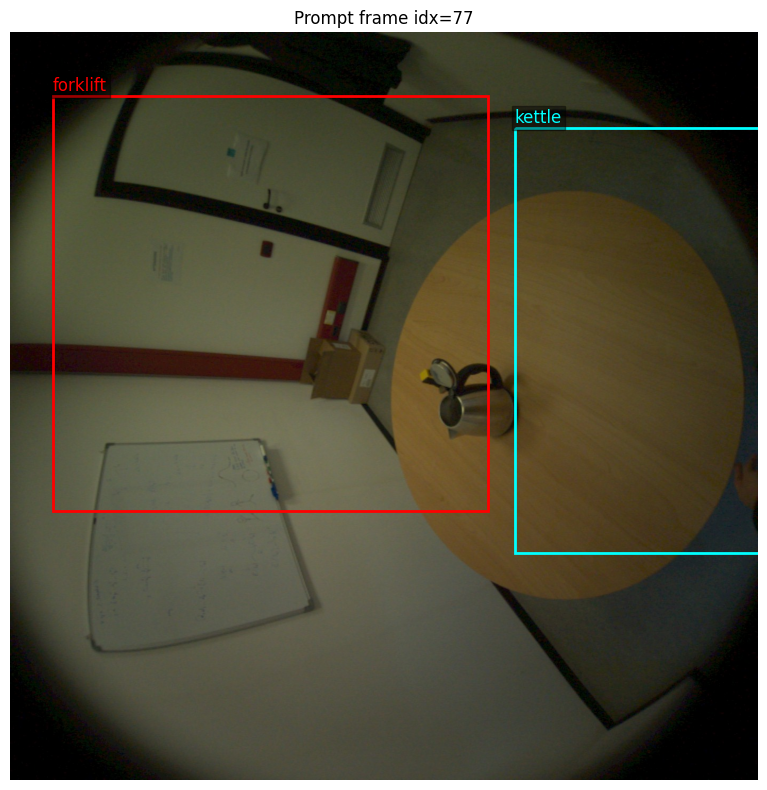

In [14]:
import matplotlib.patches as patches

# Load the prompt frame
prompt_frame = get_rgb_frame_by_index(provider, rgb_stream_id, PROMPT_FRAME_IDX)

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.imshow(prompt_frame)
ax.set_title(f"Prompt frame idx={PROMPT_FRAME_IDX}")
ax.axis("off")

# Draw boxes
colors = {
    "forklift": "red",
    "kettle": "cyan",
}

for name, box in BOX_PROMPTS.items():
    x0, y0, x1, y1 = box
    rect = patches.Rectangle(
        (x0, y0),
        x1 - x0,
        y1 - y0,
        linewidth=2,
        edgecolor=colors.get(name, "yellow"),
        facecolor="none",
    )
    ax.add_patch(rect)
    ax.text(
        x0,
        max(0, y0 - 10),
        name,
        color=colors.get(name, "yellow"),
        fontsize=12,
        bbox=dict(facecolor="black", alpha=0.4, pad=2),
    )

plt.tight_layout()
plt.show()